In [84]:
import pandas as pd
import numpy as np
import re
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

### 1. Assigning word indicies

In [49]:
data = pd.read_csv("task_A_En_test.csv")
data = data.dropna()

In [50]:
y = data['sarcastic']
X = data['text']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [52]:
index = 1
vocab = {}
for tweet in data['text']:
    tweet = str(tweet)

    # Clean text
    tweet = tweet.lower()
    tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
    tweet = tweet.strip()

    for word in tweet.split(" "):
        if word not in vocab:
            vocab[word] = index
            index += 1
        else:
            continue

In [53]:
def encode_tweet(tweet, vocab, max_len):
  if type(tweet) != str:
    tweet = str(tweet)
  tokens = tweet.lower().split()
  ids = [vocab.get(token, 1) for token in tokens]

  ids = ids[:max_len]

  padding_len = max_len - len(ids)
  ids = ids + ([0] * padding_len)

  return torch.tensor(ids)

In [54]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Return the encoded text and its label (0-4)
        x = encode_tweet(self.texts[idx], self.vocab, self.max_len)
        y = torch.tensor(self.labels[idx])
        return x, y

In [55]:
tweets = data['text'].tolist()
labels = []
for i in range(len(data['sarcastic'])):
  if data['sarcastic'].iloc[i] == 1.0: labels.append(1)
  else: labels.append(0)

dataset = TextDataset(tweets, labels, vocab, max_len=30)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [56]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, num_classes):
        super(TransformerClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(100, d_model) # max length should be < 100

        # encoder
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # classifier
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        positions = torch.arange(0, x.size(1)).expand(x.size(0), x.size(1)).to(x.device)

        x = self.embedding(x) + self.pos_embedding(positions)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)

        logits = self.fc(x)
        return logits

In [150]:
model = TransformerClassifier(vocab_size=len(vocab), d_model=128, nhead=8, num_layers=2, num_classes=2)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 5.0]))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [151]:
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for texts, labels in dataloader:
        texts, labels = texts.to(device), labels.to(device)

        # clear gradient
        optimizer.zero_grad()

        # forward pass
        outputs = model(texts)
        loss = criterion(outputs, labels)

        # backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataloader):.4f}")

Epoch [1/10], Loss: 0.6606
Epoch [2/10], Loss: 0.5906
Epoch [3/10], Loss: 0.5106
Epoch [4/10], Loss: 0.3779
Epoch [5/10], Loss: 0.3100
Epoch [6/10], Loss: 0.2353
Epoch [7/10], Loss: 0.2522
Epoch [8/10], Loss: 0.3123
Epoch [9/10], Loss: 0.3033
Epoch [10/10], Loss: 0.2634


In [152]:
def predict(text, model, vocab, max_len):
    model.eval()
    with torch.no_grad():
        input_tensor = encode_tweet(text, vocab, max_len).unsqueeze(0)
        logits = model(input_tensor.to(device))
        prediction = torch.argmax(logits, dim=1)
        return prediction.item()

In [153]:
correct = 0
for i in range(len(y_test)):
  y_hat = predict(X_test.iloc[i], model, vocab, 30)
  if y_hat == y_test.iloc[i]:
    correct += 1

print(f"Error: {round(1 - (correct / len(y_test)), 2)}")

Error: 0.09


In [154]:
y_pred = []
for i in range(len(y_test)):
  y_pred.append(predict(X_test.iloc[i], model, vocab, 30))

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.90      0.94       246
           1       0.57      0.97      0.72        34

    accuracy                           0.91       280
   macro avg       0.78      0.93      0.83       280
weighted avg       0.94      0.91      0.92       280



In [86]:
p = precision_score(y_test, y_pred)
r = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [64]:
np.sum(data['sarcastic']) / len(data['sarcastic'])

np.float64(0.14285714285714285)

In [67]:
np.sum(data['sarcastic'] == 1)

np.int64(200)

First: Experiment with changing how classes are weighed, how does it change precision, recall, and the f1-score?

In [93]:
p = []
r = []
f1 = []
error = []
for s_weight in range(1, 10):
  print(f"{s_weight}/10")
  model = TransformerClassifier(vocab_size=len(vocab), d_model=128, nhead=8, num_layers=2, num_classes=2)
  criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, s_weight]))
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

  num_epochs = 5
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)

  for epoch in range(num_epochs):
      model.train()
      total_loss = 0

      for texts, labels in dataloader:
          texts, labels = texts.to(device), labels.to(device)

          # clear gradient
          optimizer.zero_grad()

          # forward pass
          outputs = model(texts)
          loss = criterion(outputs, labels)

          # backward pass
          loss.backward()
          optimizer.step()

          total_loss += loss.item()

      print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataloader):.4f}")

  correct = 0
  y_pred = []
  for i in range(len(y_test)):
    y_pred.append(predict(X_test.iloc[i], model, vocab, 30))
    if y_pred[-1] == y_test.iloc[i]:
      correct += 1

  p.append(precision_score(y_test, y_pred))
  r.append(recall_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  error.append(1 - (correct / len(y_test)))

1/10
Epoch [1/5], Loss: 0.4200
Epoch [2/5], Loss: 0.3884
Epoch [3/5], Loss: 0.3591
Epoch [4/5], Loss: 0.2760
Epoch [5/5], Loss: 0.2037
2/10
Epoch [1/5], Loss: 0.6185
Epoch [2/5], Loss: 0.5114
Epoch [3/5], Loss: 0.4653
Epoch [4/5], Loss: 0.3914
Epoch [5/5], Loss: 0.2967
3/10
Epoch [1/5], Loss: 0.6283
Epoch [2/5], Loss: 0.5886
Epoch [3/5], Loss: 0.4847
Epoch [4/5], Loss: 0.3682
Epoch [5/5], Loss: 0.2285
4/10
Epoch [1/5], Loss: 0.6580
Epoch [2/5], Loss: 0.6087
Epoch [3/5], Loss: 0.5318
Epoch [4/5], Loss: 0.4894
Epoch [5/5], Loss: 0.3749
5/10
Epoch [1/5], Loss: 0.7407
Epoch [2/5], Loss: 0.6134
Epoch [3/5], Loss: 0.5072
Epoch [4/5], Loss: 0.3621
Epoch [5/5], Loss: 0.2602
6/10
Epoch [1/5], Loss: 0.6988
Epoch [2/5], Loss: 0.6497
Epoch [3/5], Loss: 0.6324
Epoch [4/5], Loss: 0.5428
Epoch [5/5], Loss: 0.4873
7/10
Epoch [1/5], Loss: 0.7886
Epoch [2/5], Loss: 0.6520
Epoch [3/5], Loss: 0.6003
Epoch [4/5], Loss: 0.5056
Epoch [5/5], Loss: 0.3855
8/10
Epoch [1/5], Loss: 0.7284
Epoch [2/5], Loss: 0.652

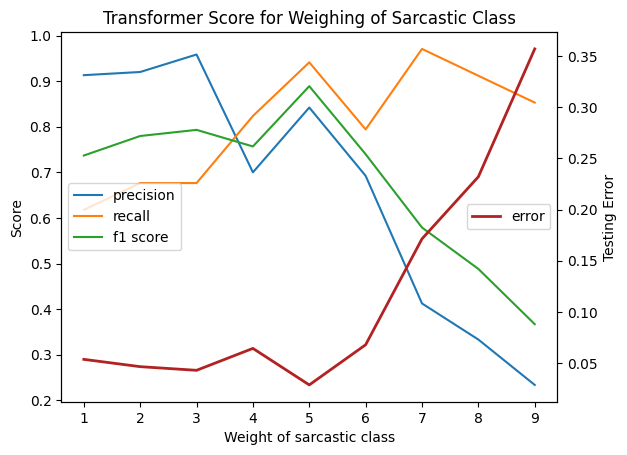

In [126]:
fig, ax = plt.subplots()

ax.plot(range(1, 10), p, label='precision')
ax.plot(range(1, 10), r, label='recall')
ax.plot(range(1, 10), f1, label='f1 score')
xa = ax.twinx()
xa.plot(range(1, 10), error, label='error', color='firebrick', linewidth=2)
xa.set_ylabel("Testing Error")

ax.set_title("Transformer Score for Weighing of Sarcastic Class")
ax.set_xlabel("Weight of sarcastic class")
ax.set_ylabel("Score")

ax.legend(loc='center left')
xa.legend(loc='center right')

Seems like to deal with the data imbalance, a weight of 5 for the sarcastic class works best.

In [111]:
p_lr = []
r_lr = []
f1_lr = []
error_lr = []
for lr in [1e-5, 1e-4, 0.001, 0.01, 0.1]:
  print(f"{lr}")
  model = TransformerClassifier(vocab_size=len(vocab), d_model=128, nhead=8, num_layers=2, num_classes=2)
  criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 5.0]))
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  num_epochs = 5
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)

  for epoch in range(num_epochs):
      model.train()
      total_loss = 0

      for texts, labels in dataloader:
          texts, labels = texts.to(device), labels.to(device)

          # clear gradient
          optimizer.zero_grad()

          # forward pass
          outputs = model(texts)
          loss = criterion(outputs, labels)

          # backward pass
          loss.backward()
          optimizer.step()

          total_loss += loss.item()

      print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataloader):.4f}")

  correct = 0
  y_pred = []
  for i in range(len(y_test)):
    y_pred.append(predict(X_test.iloc[i], model, vocab, 30))
    if y_pred[-1] == y_test.iloc[i]:
      correct += 1

  p_lr.append(precision_score(y_test, y_pred))
  r_lr.append(recall_score(y_test, y_pred))
  f1_lr.append(f1_score(y_test, y_pred))
  error_lr.append(1 - (correct / len(y_test)))

1e-05
Epoch [1/5], Loss: 0.6479
Epoch [2/5], Loss: 0.6303
Epoch [3/5], Loss: 0.6266
Epoch [4/5], Loss: 0.6236
Epoch [5/5], Loss: 0.6185
0.0001
Epoch [1/5], Loss: 0.6511
Epoch [2/5], Loss: 0.6201
Epoch [3/5], Loss: 0.6132
Epoch [4/5], Loss: 0.5902
Epoch [5/5], Loss: 0.5462
0.001
Epoch [1/5], Loss: 0.6862
Epoch [2/5], Loss: 0.6304
Epoch [3/5], Loss: 0.5395
Epoch [4/5], Loss: 0.4310
Epoch [5/5], Loss: 0.3445
0.01
Epoch [1/5], Loss: 0.7420
Epoch [2/5], Loss: 0.7037
Epoch [3/5], Loss: 0.6851
Epoch [4/5], Loss: 0.6801
Epoch [5/5], Loss: 0.6810


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.1
Epoch [1/5], Loss: 1.0655
Epoch [2/5], Loss: 0.6961
Epoch [3/5], Loss: 0.7734
Epoch [4/5], Loss: 0.7948
Epoch [5/5], Loss: 0.7562


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


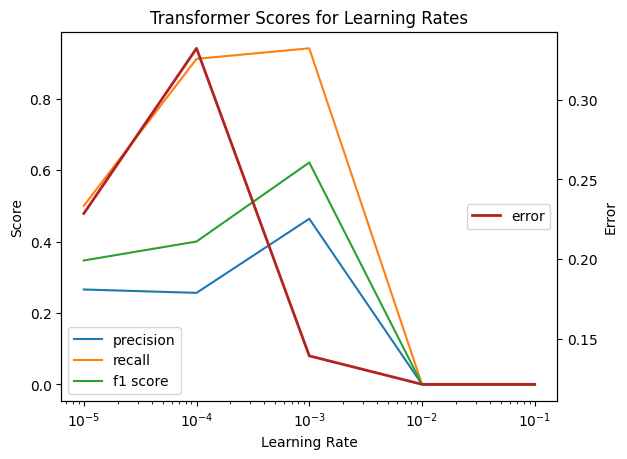

In [130]:
fig, ax = plt.subplots()

ax.plot([1e-5, 1e-4, 0.001, 0.01, 0.1], p_lr, label='precision')
ax.plot([1e-5, 1e-4, 0.001, 0.01, 0.1], r_lr, label='recall')
ax.plot([1e-5, 1e-4, 0.001, 0.01, 0.1], f1_lr, label='f1 score')
xa = ax.twinx()
xa.plot([1e-5, 1e-4, 0.001, 0.01, 0.1], error_lr, label='error', color='firebrick', linewidth=2)
xa.set_ylabel("Error")

ax.set_title("Transformer Scores for Learning Rates")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Score")

ax.legend(loc='lower left')
xa.legend(loc='center right')

ax.set_xscale('log')

Testing out attention heads/dimension change

In [134]:
p_inc = []
r_inc = []
f1_inc = []
error_inc = []
for i in range(2):
  print(f"{i}")
  model = TransformerClassifier(vocab_size=len(vocab), d_model=128*(i+1), nhead=8*(i+1), num_layers=2*(i+1), num_classes=2)
  criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 5.0]))
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

  num_epochs = 5
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)

  for epoch in range(num_epochs):
      model.train()
      total_loss = 0

      for texts, labels in dataloader:
          texts, labels = texts.to(device), labels.to(device)

          # clear gradient
          optimizer.zero_grad()

          # forward pass
          outputs = model(texts)
          loss = criterion(outputs, labels)

          # backward pass
          loss.backward()
          optimizer.step()

          total_loss += loss.item()

      print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataloader):.4f}")

  correct = 0
  y_pred = []
  for i in range(len(y_test)):
    y_pred.append(predict(X_test.iloc[i], model, vocab, 30))
    if y_pred[-1] == y_test.iloc[i]:
      correct += 1

  p_inc.append(precision_score(y_test, y_pred))
  r_inc.append(recall_score(y_test, y_pred))
  f1_inc.append(f1_score(y_test, y_pred))
  error_inc.append(1 - (correct / len(y_test)))

0
Epoch [1/5], Loss: 0.7416
Epoch [2/5], Loss: 0.6432
Epoch [3/5], Loss: 0.5830
Epoch [4/5], Loss: 0.4920
Epoch [5/5], Loss: 0.3931
1
Epoch [1/5], Loss: 0.7927
Epoch [2/5], Loss: 0.6981
Epoch [3/5], Loss: 0.6931
Epoch [4/5], Loss: 0.6895
Epoch [5/5], Loss: 0.6896


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Text(0.5, 1.0, 'Transformer Complexity Error Comparison')

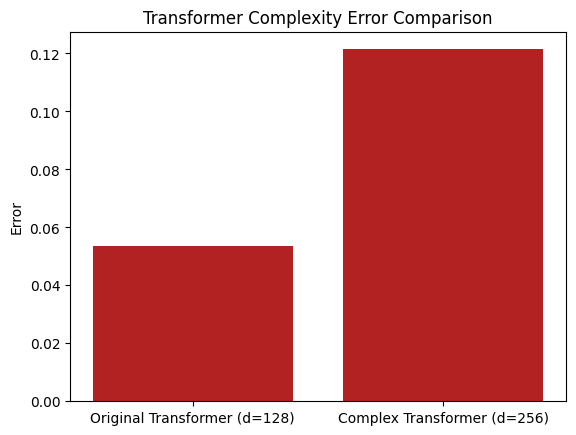

In [149]:
plt.bar(['Original Transformer (d=128)', 'Complex Transformer (d=256)'], np.array(error_inc), color='firebrick')
plt.ylabel("Error")
plt.title("Transformer Complexity Error Comparison")